# DINOv2 Zero-Shot Analysis — UAV / Drone & VTOL / Advanced Air Mobility (DeepPatent2)

**Purpose:** Extract structural embeddings from patent drawings using frozen DINOv2-Large,
then cluster the embedding space to discover structural groupings within the UAV and eVTOL
sub-domains of the DeepPatent2 dataset.

**Pipeline stages:**
1. Load `config_deeppatent.yaml` → build dataset index (images + JSON metadata)
2. Filter to `UAV / Drone` and `VTOL / Advanced Air Mobility` patents only
3. Extract DINOv2 CLS-token embeddings (frozen model, no fine-tuning)
4. L2 normalise → PCA → HDBSCAN clustering
5. UMAP visualisation (clusters vs platform ground-truth labels)
6. KNN nearest-neighbour verification (audit what features capture)
7. Dimensionality reduction comparison (raw vs PCA)
8. Export `deeppatent_analysis_matrix.xlsx`


In [1]:
# ── Stage 0: Path Configuration ──────────────────────────────────────────────
import sys
from pathlib import Path

# Make Deepatent2_Pipeline/ importable from wherever the notebook lives
sys.path.insert(0, str(Path("..").resolve()))

from src.config_loader import load_config
from src.deeppatent_loader import DeepPatent2Dataset

cfg = load_config(config_name="config_deeppatent.yaml")

# ── Output directories ────────────────────────────────────────────────────────
ANALYSIS_DIR  = Path(cfg["paths"]["outputs"]) / "zero_shot_analysis"
OUTPUT_DIR    = ANALYSIS_DIR / "outputs"
EMBEDDING_DIR = OUTPUT_DIR / "embeddings"
PLOT_DIR      = OUTPUT_DIR / "plots"

for d in [ANALYSIS_DIR, OUTPUT_DIR, EMBEDDING_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Images root : {cfg['paths']['images_root']}")
print(f"JSON labels : {cfg['paths']['json_labels']}")
print(f"Outputs     : {OUTPUT_DIR}")


Images root : /mnt/storage_11tb/Drive_files_to_syncronize/DeepPatent2
JSON labels : /mnt/storage_11tb/Drive_files_to_syncronize/DeepPatent2/Json_Files
Outputs     : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/outputs/zero_shot_analysis/outputs


In [2]:
# ── Stage 1: Hyperparameters & Dataset Indexing ──────────────────────────────
import torch
import matplotlib.pyplot as plt
from src.zero_shot import (
    initialize_dinov2, extract_embeddings,
    l2_normalize, pca_reduce, hdbscan_cluster,
    umap_project, plot_umap_clusters, plot_cluster_gallery,
    plot_knn_neighbors, plot_reduction_comparison, export_analysis_matrix,
    safe_save_np, safe_save_df, safe_save_plot,
)

SEED       = 42
MODEL_NAME = cfg["dinov2"]["model_name"]        # "facebook/dinov2-large"
BATCH_SIZE = cfg["dinov2"]["batch_size"]        # 32
DEVICE     = torch.device(cfg["dinov2"]["device"])

PCA_N_COMPONENTS          = cfg["analysis"]["pca_n_components"]
HDBSCAN_MIN_CLUSTER_SIZE  = cfg["analysis"]["hdbscan_min_cluster_size"]
HDBSCAN_MIN_SAMPLES       = cfg["analysis"]["hdbscan_min_samples"]
HDBSCAN_CLUSTER_SELECTION = cfg["analysis"]["hdbscan_cluster_selection"]
KNN_K                     = cfg["analysis"]["knn_k"]

print(f"Model : {MODEL_NAME}  |  Device: {DEVICE}  |  Batch: {BATCH_SIZE}")
print(f"PCA   : {PCA_N_COMPONENTS}d  |  HDBSCAN min_cluster_size={HDBSCAN_MIN_CLUSTER_SIZE}, "
      f"min_samples={HDBSCAN_MIN_SAMPLES}, method={HDBSCAN_CLUSTER_SELECTION}")

# ── Build dataset index ───────────────────────────────────────────────────────
# Scans extracted year folders, loads JSON annotations, classifies patents by
# platform keyword matching, and filters to UAV/Drone + VTOL/AAM only.
dataset     = DeepPatent2Dataset(cfg)
image_paths = dataset.get_image_paths()
img_df      = dataset.build_dataframe()

print(f"\nImages to embed: {len(image_paths)}")
print(f"Active platforms: {cfg['dataset']['active_platforms']}")
print(img_df['platform'].value_counts().to_string())


Model : facebook/dinov2-large  |  Device: cuda:1  |  Batch: 32
PCA   : 100d  |  HDBSCAN min_cluster_size=15, min_samples=5, method=leaf
[DeepPatent2Dataset] Indexed 1169203 images across 11 year(s): 2007, 2008, 2009, 2010, 2011, 2013, 2016, 2018, 2019, 2019part3, 2020
  [warning] JSON not found: /mnt/storage_11tb/Drive_files_to_syncronize/DeepPatent2/Json_Files/segmentation_2007.json
[DeepPatent2Dataset] Metadata: 1338591 annotations matched to 1062655 figure files, 177743 unique patents.
  Platform 'UAV / Drone': 156 patents
  Platform 'VTOL / Advanced Air Mobility': 12 patents
[DeepPatent2Dataset] Platform filter ['UAV / Drone', 'VTOL / Advanced Air Mobility']: kept 1196 images, removed 1168007.
[DeepPatent2Dataset] DataFrame: 1196 rows, 168 unique patents, {'UAV / Drone': 1103, 'VTOL / Advanced Air Mobility': 93}

Images to embed: 1196
Active platforms: ['UAV / Drone', 'VTOL / Advanced Air Mobility']
platform
UAV / Drone                     1103
VTOL / Advanced Air Mobility      93


In [3]:
# ── Stage 2: Embedding Extraction ────────────────────────────────────────────
# Extracts a 1024-d CLS-token embedding per image using frozen DINOv2-Large.
# Images are processed in batches; mean-pooled patent-level embeddings are
# also computed (patent_emb) for downstream clustering.

processor, model = initialize_dinov2(MODEL_NAME, DEVICE)

image_emb, img_meta_df, patent_ids, patent_emb = extract_embeddings(
    image_paths, processor, model, DEVICE, BATCH_SIZE
)

safe_save_np(patent_emb,  EMBEDDING_DIR / "patent_embeddings.npy")
safe_save_np(image_emb,   EMBEDDING_DIR / "image_embeddings.npy")
safe_save_df(img_meta_df, EMBEDDING_DIR / "image_metadata.csv")


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Extracting embeddings: 100%|██████████| 38/38 [00:20<00:00,  1.89it/s]

Image embeddings:  (1196, 1024)
Patent embeddings: (168, 1024)  (168 unique patents)


PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/outputs/zero_shot_analysis/outputs/embeddings/image_metadata_1780438944.csv')

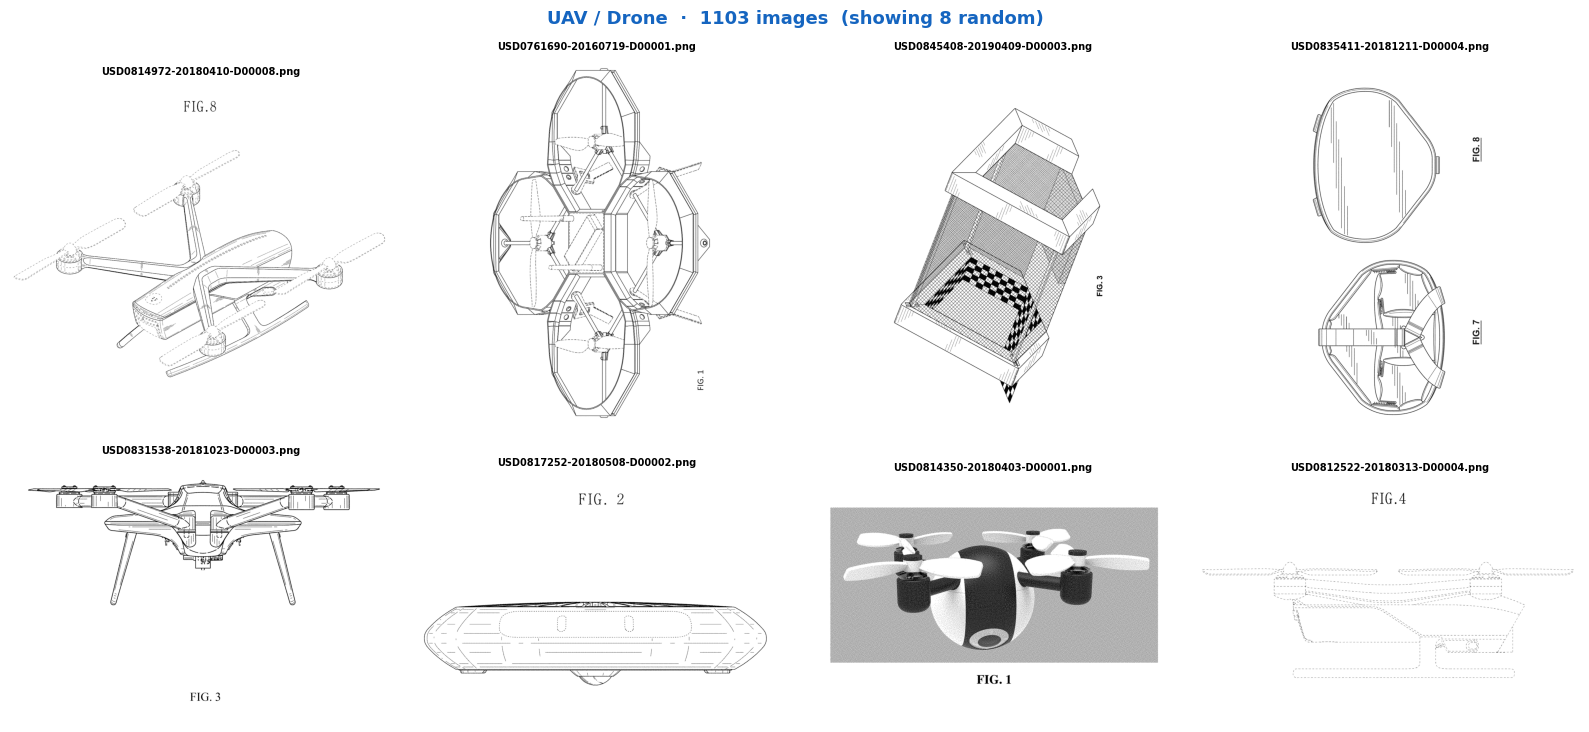

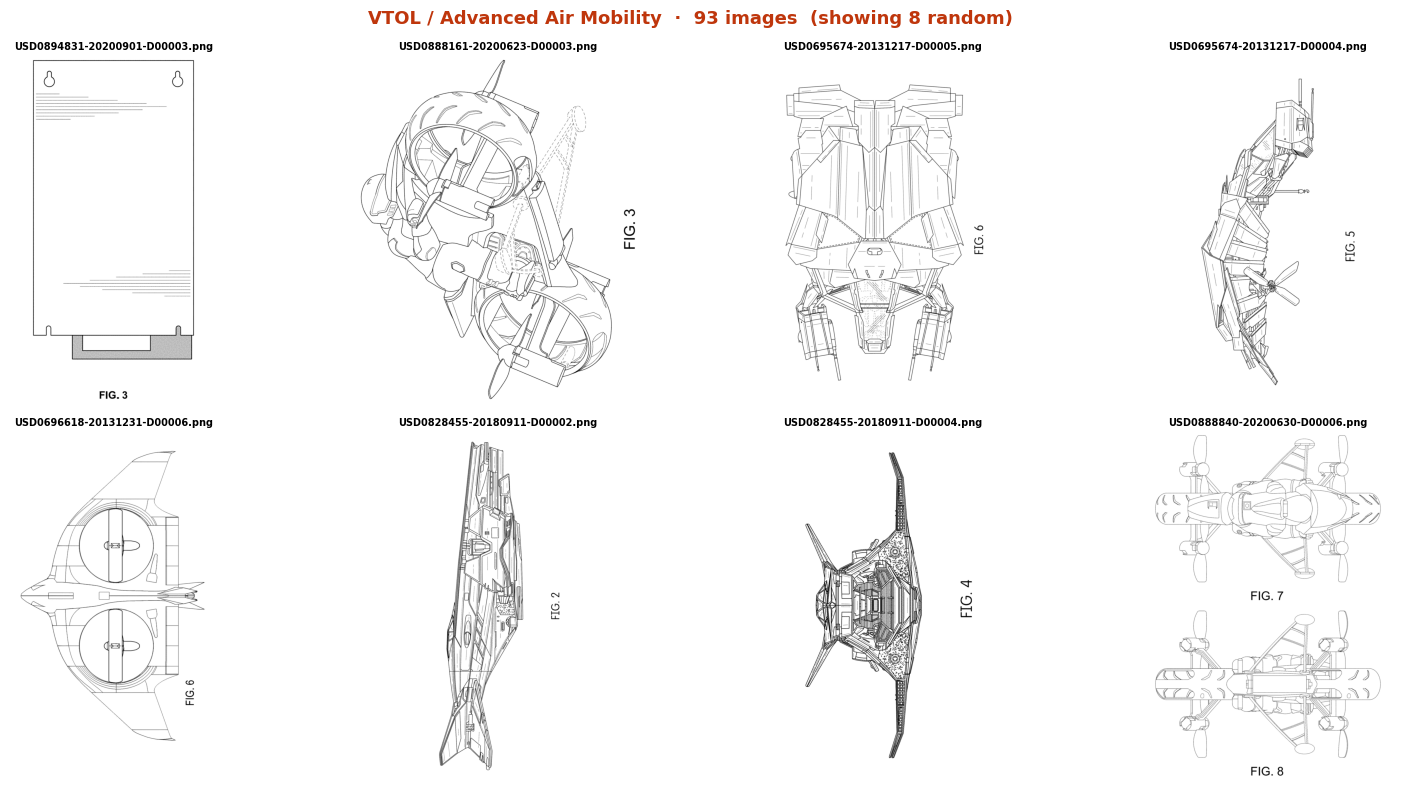


Images per platform:
  UAV / Drone: 1103
  VTOL / Advanced Air Mobility: 93


In [4]:
# ── Stage 2.5: Label Quality Check ───────────────────────────────────────────
# Visually inspect a random sample of images per platform to confirm the
# keyword-based filter is capturing the right patents.
import random
import numpy as np
from PIL import Image as _PIL_Image

N_SHOW = 8  # images to sample per platform

by_platform = {}
for p in image_paths:
    lbl = dataset.get_platform_label(p)
    by_platform.setdefault(lbl, []).append(p)

rng = random.Random(SEED)
platform_colors = {
    "UAV / Drone":                    "#1565C0",
    "VTOL / Advanced Air Mobility":   "#BF360C",
}

for plat, paths in sorted(by_platform.items()):
    sample = rng.sample(paths, min(N_SHOW, len(paths)))
    ncols  = 4
    nrows  = -(-len(sample) // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, p in zip(axes, sample):
        ax.imshow(_PIL_Image.open(p).convert("RGB"))
        ax.set_title(p.name[:30], fontsize=7, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")

    color = platform_colors.get(plat, "#37474F")
    fig.suptitle(
        f"{plat}  ·  {len(paths)} images  (showing {len(sample)} random)",
        fontsize=13, fontweight="bold", color=color,
    )
    fig.tight_layout()
    safe_save_plot(fig, PLOT_DIR / f"label_check_{plat.replace('/', '_').replace(' ', '_')}.png",
                   dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("\nImages per platform:")
for plat, paths in sorted(by_platform.items()):
    print(f"  {plat}: {len(paths)}")


In [5]:
# ── Stage 2a: Frozen Baseline Embeddings (Pre-analysis Reference) ─────────────
"""
What this cell does:
- Saves a dedicated copy of the raw DINOv2 CLS-token embeddings (as produced by
  Stage 2) to EMBEDDING_DIR / "frozen" / before any normalization or PCA alters them.
- Since this is a zero-shot pipeline the model is already frozen — the embeddings
  produced in Stage 2 ARE the frozen baseline.

Why it must run BEFORE Stage 3 (L2 normalization) and Stage 3.5 (PCA):
- Stage 3 projects patent_emb onto the unit hypersphere (destructive in-place
  semantics for X_norm); Stage 3.5 reduces to 50 dimensions. The frozen folder
  preserves the full 1024-d vectors so expert-correlation analysis uses the
  same scale as cosine similarity in the raw embedding space.
- If a fine-tuned variant is added later you will need a fixed pre-training
  snapshot in the same folder to compare against.
"""

import numpy as np
import pandas as pd

frozen_emb_dir = EMBEDDING_DIR / "frozen"
frozen_emb_dir.mkdir(parents=True, exist_ok=True)

_frozen_emb_path  = frozen_emb_dir / "patent_embeddings_frozen.npy"
_frozen_meta_path = frozen_emb_dir / "patent_metadata_frozen.csv"

# patent_emb and patent_ids come from Stage 2; save directly (no timestamp
# suffix) so Stage 2b can load from a stable, known path.
np.save(_frozen_emb_path, patent_emb)
pd.DataFrame({"patent_id": patent_ids}).to_csv(_frozen_meta_path, index=False)

print(f"Frozen patent embeddings shape : {patent_emb.shape}")
print(f"Saved embeddings  : {_frozen_emb_path}")
print(f"Saved metadata    : {_frozen_meta_path}")


Frozen patent embeddings shape : (168, 1024)
Saved embeddings  : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/outputs/zero_shot_analysis/outputs/embeddings/frozen/patent_embeddings_frozen.npy
Saved metadata    : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/outputs/zero_shot_analysis/outputs/embeddings/frozen/patent_metadata_frozen.csv


In [6]:
# ── Stage 2b: Frozen Embedding Validation (Expert Correlation) ────────────────
"""
What this cell does:
- Reads expert-rated patent pairs from EMBEDDING_DIR / "frozen" / "expert_pairs.csv".
- Looks up frozen embeddings for each pair, L2-normalises them, and computes cosine
  similarity.
- Correlates cosine similarities with human design-similarity scores via Spearman rho.
- Saves a scatter plot (expert score vs cosine similarity) to PLOT_DIR.

Why it must run BEFORE normalization and clustering (Stages 3–4):
- You need a pre-pipeline baseline to quantify whether DINOv2 already captures
  design similarity before any dimensionality reduction or cluster-specific choices.
  rho > 0.5 → usable off-the-shelf; 0.3–0.5 → weak signal; < 0.3 → poor baseline.
- Results from this cell form the left column of your results table and give a
  reference point for interpreting cluster quality in Stage 4.
"""

import numpy as np
import pandas as pd
import scipy.stats

_expert_pairs_path = EMBEDDING_DIR / "frozen" / "expert_pairs.csv"
_frozen_emb_path   = EMBEDDING_DIR / "frozen" / "patent_embeddings_frozen.npy"
_frozen_meta_path  = EMBEDDING_DIR / "frozen" / "patent_metadata_frozen.csv"

if not _expert_pairs_path.exists():
    print("=" * 70)
    print("expert_pairs.csv not found. To create it:")
    print("=" * 70)
    print(f"  Path expected : {_expert_pairs_path}")
    print()
    print("  Create a CSV with these columns:")
    print("    patent_id_a, patent_id_b, expert_score")
    print()
    print("  Guidelines:")
    print("  - Include ~50 pairs drawn at random from your patent pool.")
    print("  - expert_score is an integer 1–5 (1 = very different, 5 = very similar),")
    print("    based on the visual design of the aircraft in the patent drawings.")
    print("  - Scoring must be done blind to the model (do not look at embeddings).")
    print("  - Use at least two independent raters and average their scores if possible.")
    print()
    print("  Once the file is ready, re-run this cell.")
    print("=" * 70)
else:
    _pairs_df    = pd.read_csv(_expert_pairs_path)
    _frozen_embs = np.load(_frozen_emb_path)
    _frozen_meta = pd.read_csv(_frozen_meta_path)
    _id_to_idx   = {pid: i for i, pid in enumerate(_frozen_meta["patent_id"])}

    _cosine_sims   = []
    _expert_scores = []
    _skipped       = []

    for _, row in _pairs_df.iterrows():
        pid_a, pid_b = str(row["patent_id_a"]), str(row["patent_id_b"])
        if pid_a not in _id_to_idx or pid_b not in _id_to_idx:
            _skipped.append((pid_a, pid_b))
            continue
        emb_a = _frozen_embs[_id_to_idx[pid_a]]
        emb_b = _frozen_embs[_id_to_idx[pid_b]]
        emb_a = emb_a / (np.linalg.norm(emb_a) + 1e-8)
        emb_b = emb_b / (np.linalg.norm(emb_b) + 1e-8)
        _cosine_sims.append(float(np.dot(emb_a, emb_b)))
        _expert_scores.append(float(row["expert_score"]))

    if _skipped:
        print(f"Skipped {len(_skipped)} pairs (IDs not in frozen embeddings): {_skipped[:5]}")

    if len(_cosine_sims) < 3:
        print("Too few valid pairs to compute correlation. Add more pairs or fix patent IDs.")
    else:
        rho, pval = scipy.stats.spearmanr(_expert_scores, _cosine_sims)

        if rho > 0.5:
            interpretation = "Usable representation — off-the-shelf DINOv2 already tracks design similarity."
        elif rho > 0.3:
            interpretation = "Weak correlation — frozen model has partial signal; PCA / clustering may still separate classes."
        else:
            interpretation = "Poor correlation — the frozen embedding is not tracking design similarity in this domain."

        print(f"Spearman rho = {rho:.3f}   p-value = {pval:.4f}")
        print(f"Interpretation: {interpretation}")
        print(f"Valid pairs used: {len(_cosine_sims)} / {len(_pairs_df)}")

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(_expert_scores, _cosine_sims, alpha=0.7, edgecolors="k", linewidths=0.5)
        ax.set_xlabel("Expert Design-Similarity Score (1\u20135)")
        ax.set_ylabel("Cosine Similarity (frozen DINOv2)")
        ax.set_title(
            f"Frozen Baseline Validation\n"
            f"Spearman \u03c1 = {rho:.3f},  p = {pval:.4f}"
        )
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        _plot_path = safe_save_plot(fig, PLOT_DIR / "frozen_expert_correlation.png", dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved plot: {_plot_path}")


expert_pairs.csv not found. To create it:
  Path expected : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/outputs/zero_shot_analysis/outputs/embeddings/frozen/expert_pairs.csv

  Create a CSV with these columns:
    patent_id_a, patent_id_b, expert_score

  Guidelines:
  - Include ~50 pairs drawn at random from your patent pool.
  - expert_score is an integer 1–5 (1 = very different, 5 = very similar),
    based on the visual design of the aircraft in the patent drawings.
  - Scoring must be done blind to the model (do not look at embeddings).
  - Use at least two independent raters and average their scores if possible.

  Once the file is ready, re-run this cell.


In [7]:
# ── Stage 3: L2 Normalization ─────────────────────────────────────────────────
# Projects each 1024-d embedding vector onto the unit hypersphere (length = 1).
# After this, Euclidean distance is equivalent to cosine distance —
# so clustering groups patents by the *direction* (structure) of their embeddings,
# not by their magnitude.
X_norm = l2_normalize(patent_emb)

L2-normalized 168 vectors — mean norm: 1.000000, std: 8.75e-08


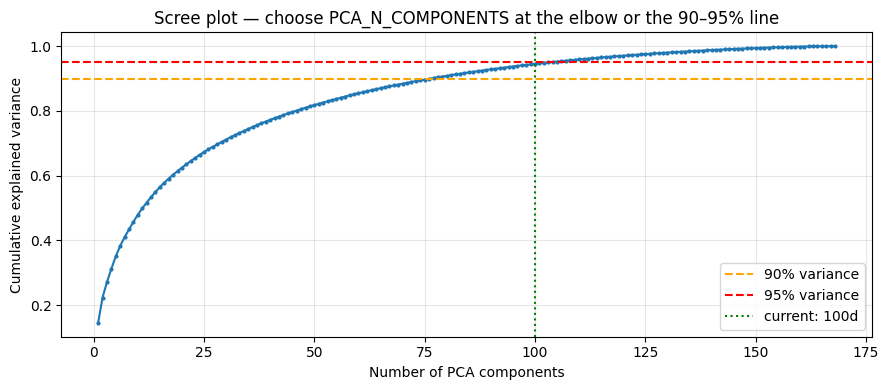

Components for 90% variance: 77
Components for 95% variance: 104
Current PCA_N_COMPONENTS   : 100


In [8]:
# ── Stage 3.5a: Scree Plot — choose PCA n_components ─────────────────────────
# With 84 samples, PCA can produce at most 84 components (not 1024).
# This plot shows how many components are actually needed to capture the variance.
# Look for the "elbow" — the point where the curve flattens.
# Then set PCA_N_COMPONENTS in Stage 1 to that value and re-run from Stage 3.5b.
import numpy as np
from sklearn.decomposition import PCA as _PCA

pca_full = _PCA().fit(X_norm)
cumvar   = pca_full.explained_variance_ratio_.cumsum()

fig_scree, ax_scree = plt.subplots(figsize=(9, 4))
ax_scree.plot(range(1, len(cumvar) + 1), cumvar, marker=".", markersize=4)
ax_scree.axhline(0.90, color="orange", linestyle="--", label="90% variance")
ax_scree.axhline(0.95, color="red",    linestyle="--", label="95% variance")
ax_scree.axvline(PCA_N_COMPONENTS, color="green", linestyle=":", label=f"current: {PCA_N_COMPONENTS}d")
ax_scree.set_xlabel("Number of PCA components")
ax_scree.set_ylabel("Cumulative explained variance")
ax_scree.set_title("Scree plot — choose PCA_N_COMPONENTS at the elbow or the 90–95% line")
ax_scree.legend()
ax_scree.grid(alpha=0.3)
plt.tight_layout()
safe_save_plot(fig_scree, PLOT_DIR / "pca_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# Print exact component counts for 90% and 95%
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1
print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")
print(f"Current PCA_N_COMPONENTS   : {PCA_N_COMPONENTS}")

In [9]:
# ── Stage 3.5: PCA Dimensionality Reduction ───────────────────────────────────
# DINOv2-large produces 1024-d vectors. In very high dimensions, all pairwise
# distances converge to the same value (curse of dimensionality), making
# distance-based clustering unreliable. PCA keeps the most discriminative
# directions and reduces the space to 100 dimensions (advisor recommendation).
X_pca = pca_reduce(X_norm, n_components=PCA_N_COMPONENTS, seed=SEED)
safe_save_np(X_pca, EMBEDDING_DIR / "patent_embeddings_pca.npy")

PCA: 1024d → 100d  |  variance explained: 94.5%


PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/outputs/zero_shot_analysis/outputs/embeddings/patent_embeddings_pca_1780438951.npy')

In [10]:
# ── Stage 4: HDBSCAN Clustering ──────────────────────────────────────────────
cluster_df, patent_cluster_labels = hdbscan_cluster(
    X_pca,
    patent_ids,
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
)
saved = safe_save_df(cluster_df, OUTPUT_DIR / "patent_cluster_assignments_hdbscan.csv")
print(f"Assignments saved: {saved.name}")
print(cluster_df.to_string(index=False))

HDBSCAN (min_cluster_size=15, min_samples=5, method=leaf): 0 cluster(s), 168 noise point(s) / 168 total
Assignments saved: patent_cluster_assignments_hdbscan_1780438951.csv
          patent_id  cluster_id  cluster_prob
USD0695674-20131217          -1           0.0
USD0696618-20131231          -1           0.0
USD0747775-20160119          -1           0.0
USD0751025-20160308          -1           0.0
USD0755703-20160510          -1           0.0
USD0756022-20160510          -1           0.0
USD0756028-20160510          -1           0.0
USD0756842-20160524          -1           0.0
USD0759764-20160621          -1           0.0
USD0760624-20160705          -1           0.0
USD0761690-20160719          -1           0.0
USD0763133-20160809          -1           0.0
USD0763134-20160809          -1           0.0
USD0766159-20160913          -1           0.0
USD0767043-20160920          -1           0.0
USD0769985-20161025          -1           0.0
USD0770940-20161108          -1           0.0

Computing UMAP 2D projection (may take ~30 s on CPU)...


/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ UMAP complete: (168, 2)


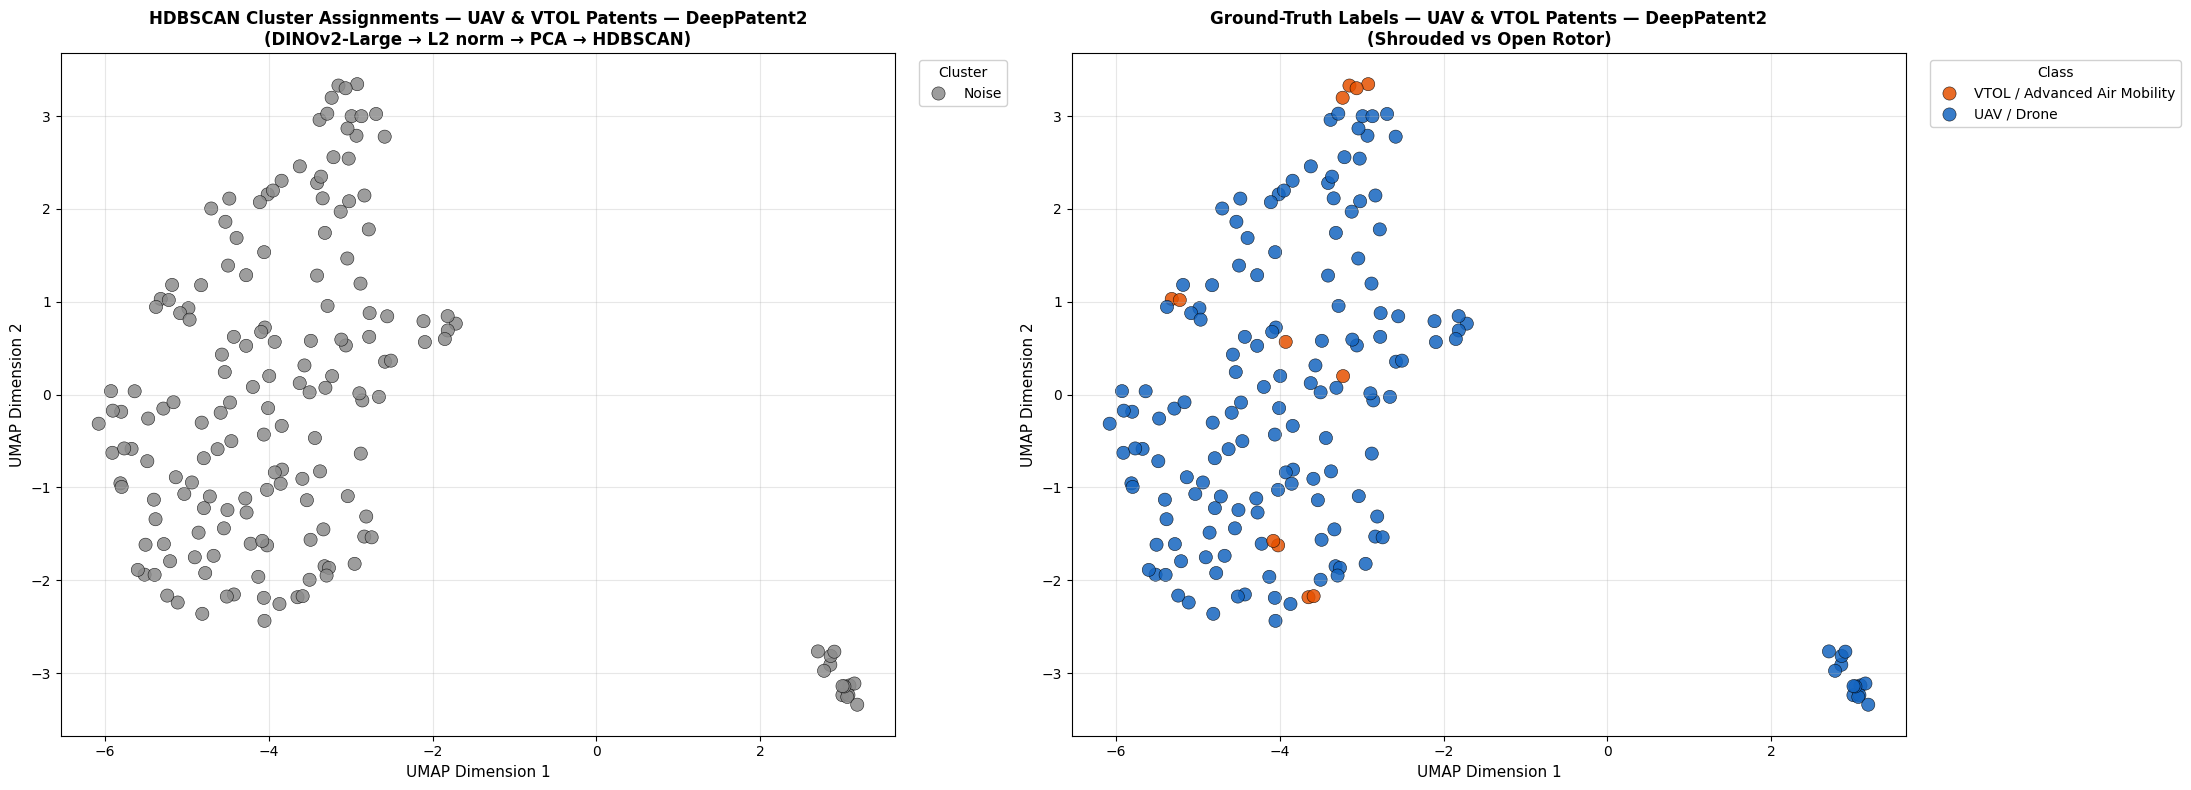

In [11]:
# ── Stage 5: UMAP Visualization ──────────────────────────────────────────────
# Left panel  — HDBSCAN cluster assignments
# Right panel — Platform ground-truth labels (UAV / Drone vs VTOL / AAM)
points_2d = umap_project(X_pca, seed=SEED)

# Build per-patent platform ground-truth from dataset
pid_to_platform = {}
for p in image_paths:
    pid = p.name.rsplit("-D", 1)[0]  # patent_id_from_path logic
    if pid not in pid_to_platform:
        pid_to_platform[pid] = dataset.get_platform_label(p)
gt_labels = [pid_to_platform.get(pid, "Other") for pid in patent_ids]

fig = plot_umap_clusters(
    points_2d,
    patent_cluster_labels,
    patent_ids,
    title_suffix="UAV & VTOL Patents — DeepPatent2",
    ground_truth_labels=gt_labels,
)
safe_save_plot(fig, PLOT_DIR / "patent_clusters_umap.png", dpi=220, bbox_inches="tight")
plt.show()

plot_cluster_gallery(cluster_df, patent_ids, image_paths, PLOT_DIR)


---

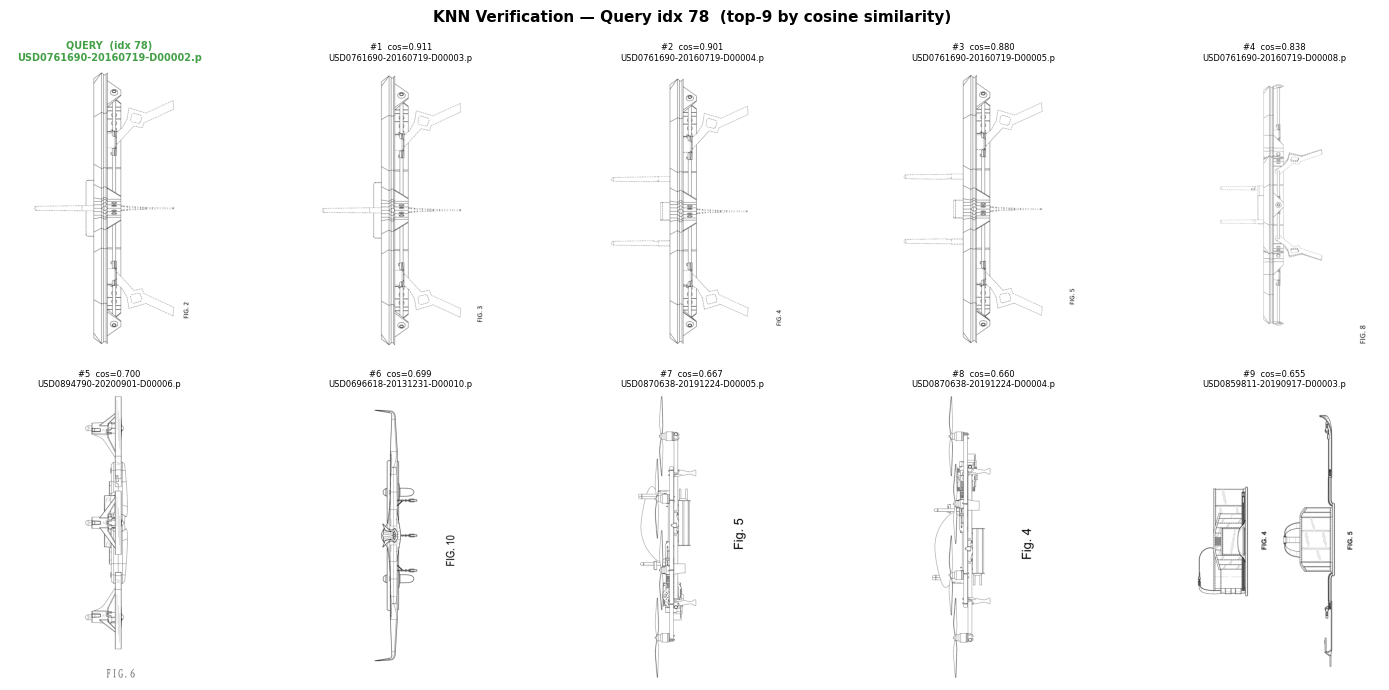

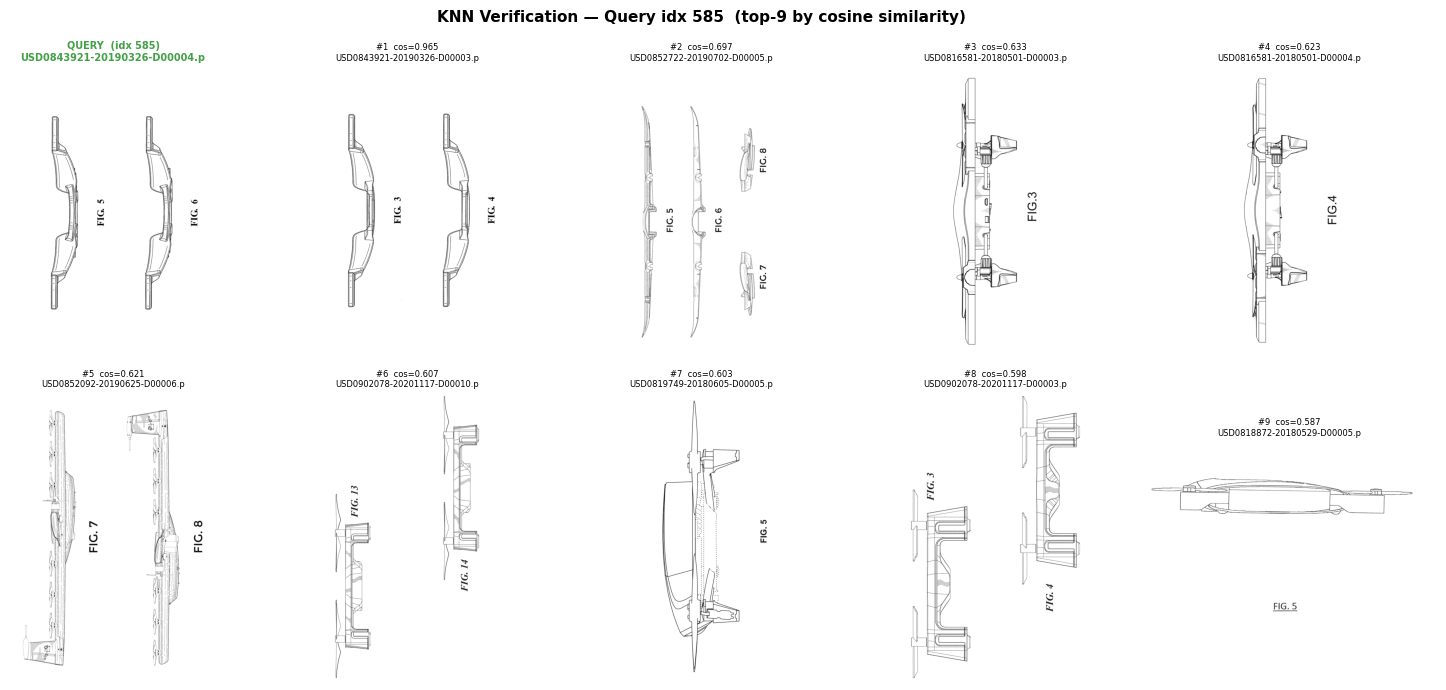

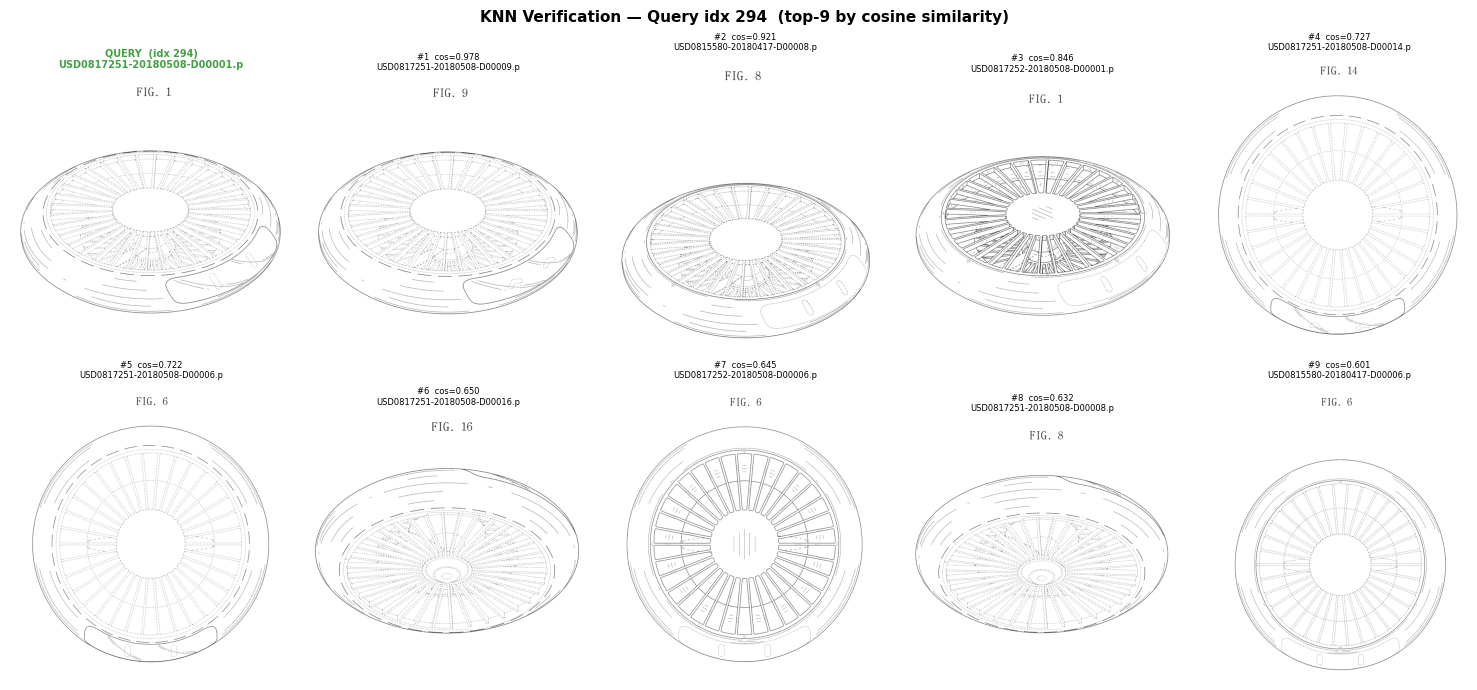

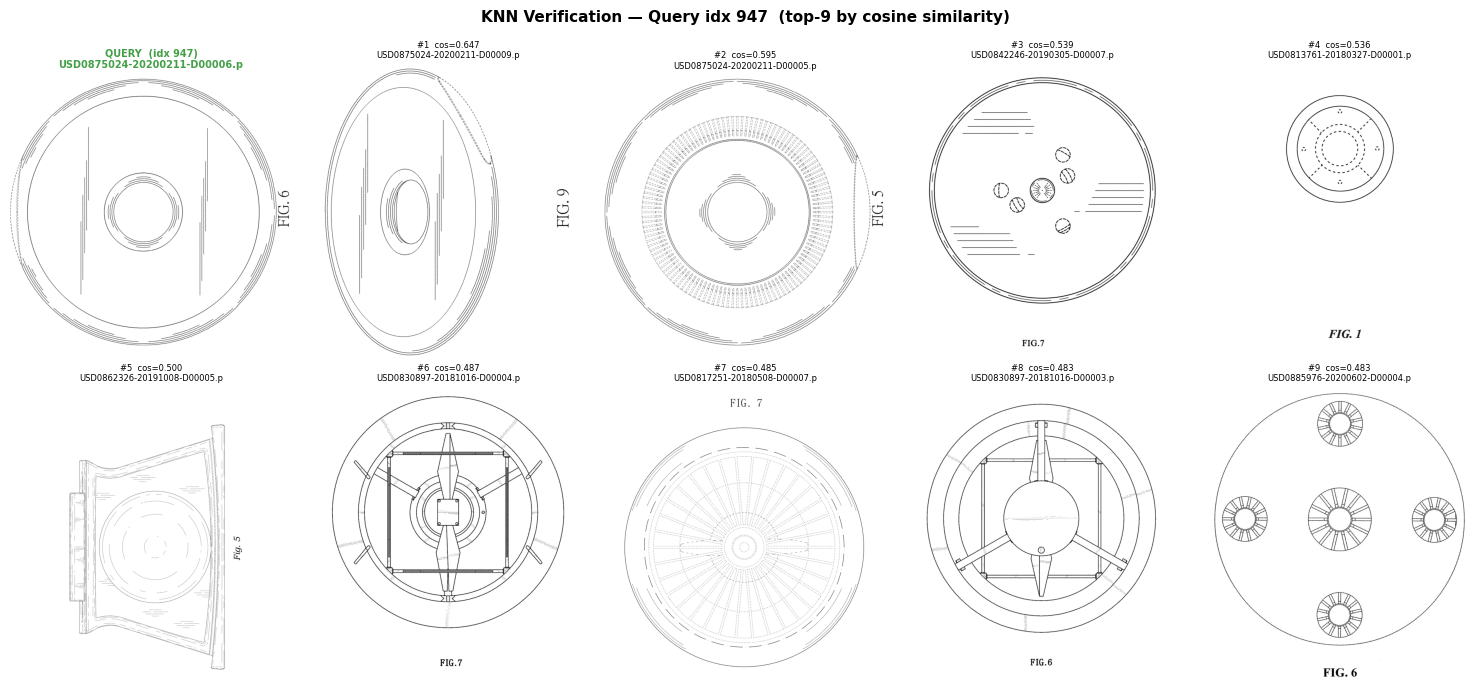

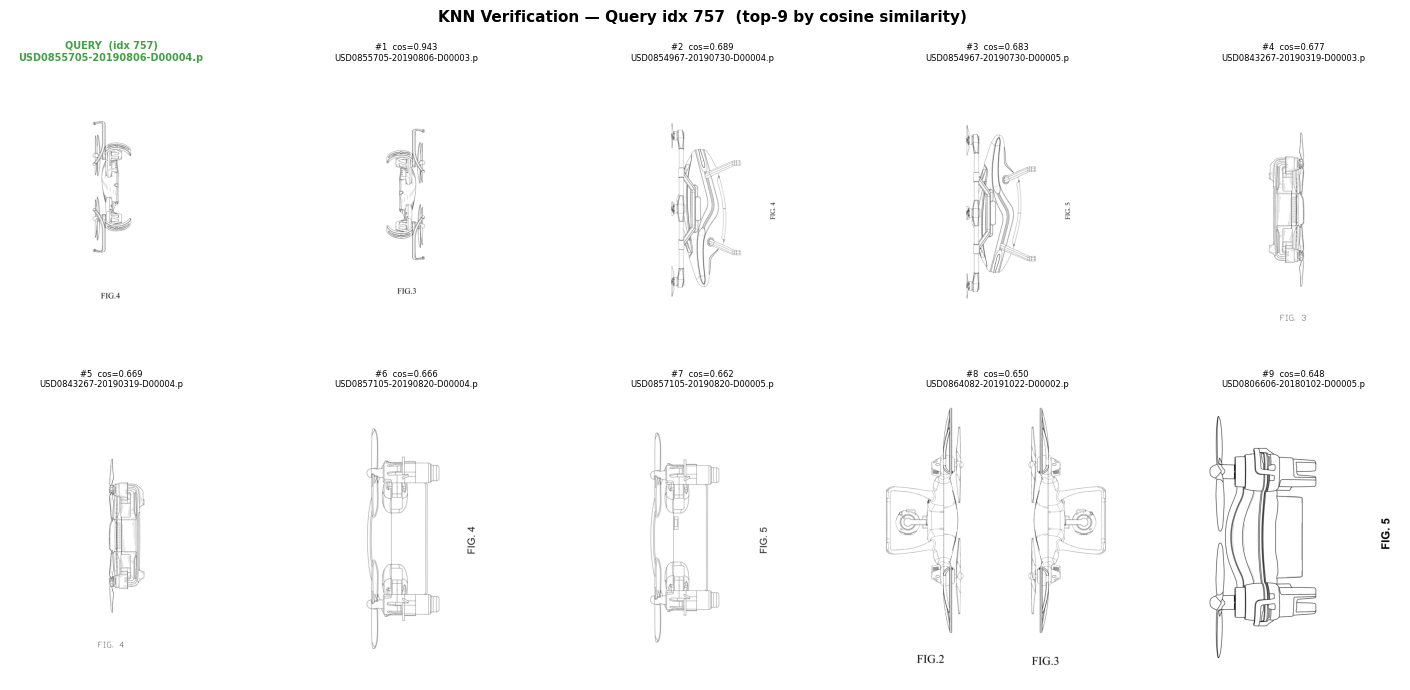

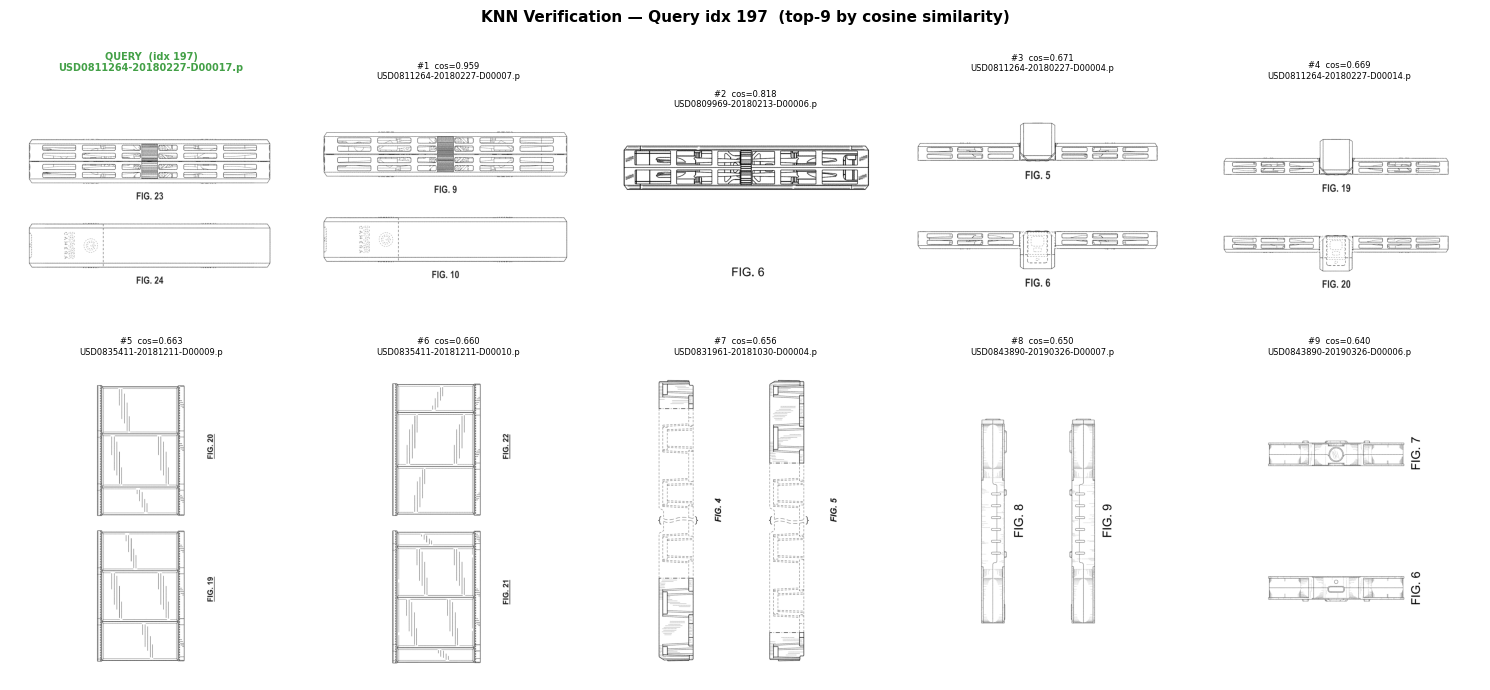

In [12]:
# ── Stage 6: KNN Nearest-Neighbour Verification ─────────────────────────────
# Pick several random query images and display their K nearest neighbours in
# embedding space.  This is the fastest way to diagnose what DINOv2 has actually
# learned: if neighbours share drawing-office style rather than structural
# geometry, the raw embeddings need PCA / fine-tuning before clustering is useful.

import random as _random
import re as _re

N_QUERIES = 6   # how many random queries to inspect
rng_q = _random.Random(SEED + 1)
query_indices = rng_q.sample(range(len(image_paths)), min(N_QUERIES, len(image_paths)))

for q_idx in query_indices:
    fig = plot_knn_neighbors(q_idx, image_paths, image_emb, k=KNN_K)
    safe_save_plot(fig, PLOT_DIR / f"knn_query_{q_idx:06d}.png",
                   dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


---

Computing shared UMAP projection…
HDBSCAN on raw 1024-d embeddings…


/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA 1024d → 100d then HDBSCAN…
Raw  : 0 clusters, 168 noise
PCA  : 0 clusters, 168 noise  (94.5% variance in 100d)


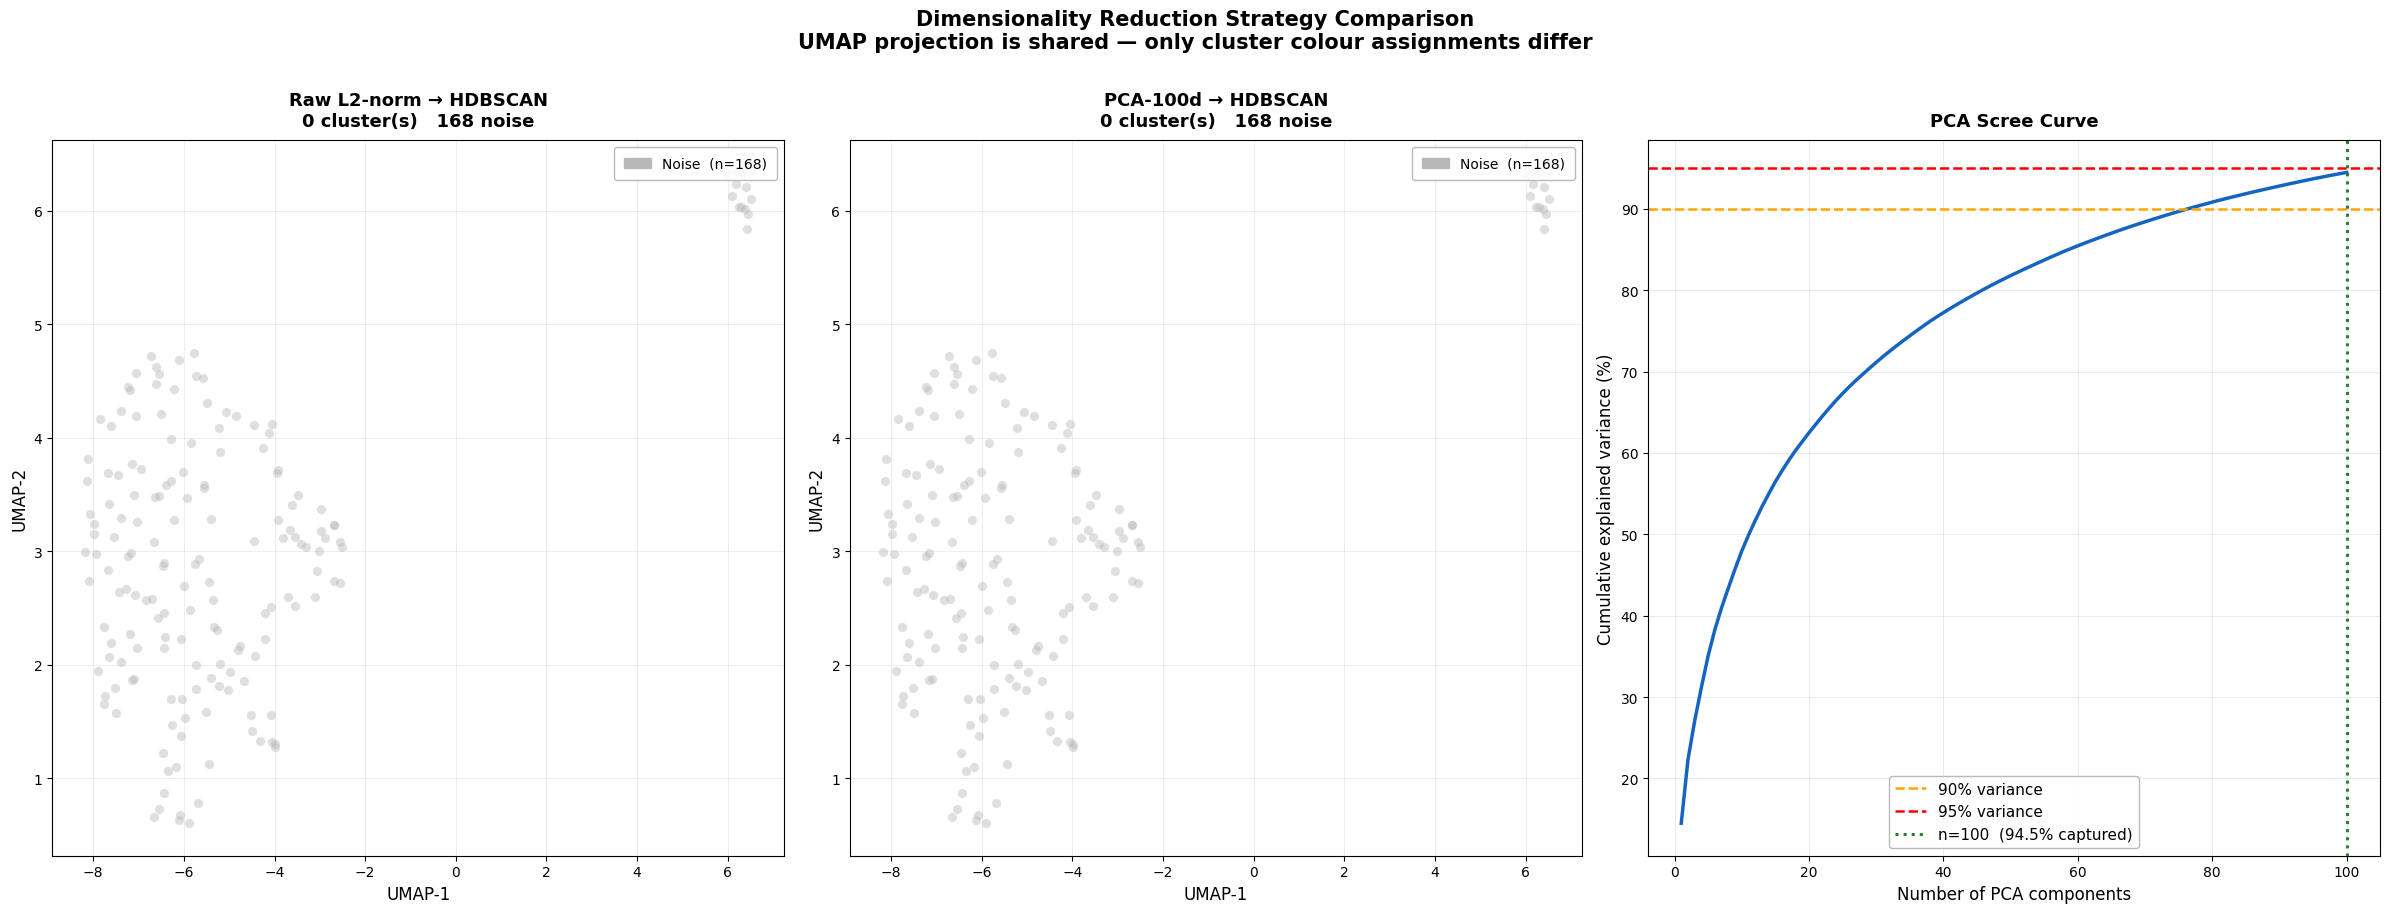

In [13]:
# ── Stage 7: Dimensionality Reduction Strategy Comparison ───────────────────
# Side-by-side comparison:
#   LEFT  — HDBSCAN on raw L2-normalised patent embeddings (1024-d)
#   MIDDLE — HDBSCAN on PCA-reduced patent embeddings (PCA_N_COMPONENTS-d)
#   RIGHT  — PCA scree curve
#
# Both scatter panels share the same UMAP 2D projection so spatial positions
# are directly comparable; only the cluster colour assignments differ.
#
# If PCA produces tighter, more coherent clusters the high-d space contained
# significant stylistic noise that PCA filtered out.  If results are similar,
# the top variance directions already dominate the embedding.

fig = plot_reduction_comparison(
    patent_emb,
    patent_ids,
    hdbscan_min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    hdbscan_min_samples=HDBSCAN_MIN_SAMPLES,
    pca_n_components=PCA_N_COMPONENTS,
    seed=SEED,
)
safe_save_plot(fig, PLOT_DIR / "reduction_strategy_comparison.png",
               dpi=150, bbox_inches="tight")
plt.show()


---

In [14]:
# ── Stage 8: Cluster Quality Summary ────────────────────────────────────────
# Collects and prints all quality metrics computed during Stage 4 (HDBSCAN).
# Use this cell to quickly compare runs after tuning hyperparameters.

from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

mask = patent_cluster_labels != -1
n_clusters = len(set(patent_cluster_labels) - {-1})
n_noise    = int(np.sum(patent_cluster_labels == -1))
n_total    = len(patent_cluster_labels)

print("=" * 55)
print("Cluster Quality Summary")
print("=" * 55)
print(f"Total patents   : {n_total}")
print(f"Clusters found  : {n_clusters}")
print(f"Noise points    : {n_noise}  ({n_noise/n_total*100:.1f}%)")

if n_clusters >= 2 and mask.sum() >= 2:
    sil = silhouette_score(X_pca[mask], patent_cluster_labels[mask])
    db  = davies_bouldin_score(X_pca[mask], patent_cluster_labels[mask])
    print(f"Silhouette score: {sil:.4f}  (closer to 1.0 = tighter clusters)")
    print(f"Davies-Bouldin  : {db:.4f}  (closer to 0.0 = better separation)")
else:
    print("Too few clusters for quality metrics.")

print()
print("Cluster breakdown:")
for cid, grp in cluster_df.groupby("cluster_id"):
    label = "Noise" if cid == -1 else f"Cluster {cid}"
    print(f"  {label:12s}: {len(grp):4d} patents")


Cluster Quality Summary
Total patents   : 168
Clusters found  : 0
Noise points    : 168  (100.0%)
Too few clusters for quality metrics.

Cluster breakdown:
  Noise       :  168 patents


---

In [15]:
# ── Stage 9: Excel Metadata & Labelling Export ───────────────────────────────
# Compiles the full analysis matrix into a formatted .xlsx file.
#
# Columns: Image_ID | File_Path | Patent_ID | Year | Platform |
#          Object_Title | Aspect_Views | BBox_Count | Caption_Sample |
#          Cluster_ID | Cluster_Prob
#
# Platform column enables filtering between UAV/Drone and VTOL/AAM in Excel.
# Cluster_ID = -1 means the patent was flagged as noise by HDBSCAN.

excel_path   = Path(cfg["paths"]["outputs"]) / cfg["outputs"]["excel_filename"]
analysis_df  = export_analysis_matrix(
    image_paths=image_paths,
    dataset_df=img_df,
    cluster_df=cluster_df,
    output_path=excel_path,
)

print(f"\nOutput path  : {excel_path}")
print(f"Shape        : {analysis_df.shape}")
analysis_df.head(10)


[export_analysis_matrix] 1196 rows | 1 unique cluster IDs | 1196 noise images
Saved → /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/outputs/deeppatent_analysis_matrix.xlsx

Output path  : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent_Images_Extractor_&_FT_2.0/Deepatent2_Pipeline/outputs/deeppatent_analysis_matrix.xlsx
Shape        : (1196, 11)


,Image_ID,File_Path,Patent_ID,Year,Platform,Object_Title,Aspect_Views,BBox_Count,Caption_Sample,Cluster_ID,Cluster_Prob
0,USD0695674-20131217-D00001,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0695674-20131217,2013,VTOL / Advanced Air Mobility,Flying vehicle and/or toy replica thereof,front perspective view,1,FIG. 1 is a front perspective view of a flying...,-1,0.0
1,USD0695674-20131217-D00002,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0695674-20131217,2013,VTOL / Advanced Air Mobility,Flying vehicle and/or toy replica thereof,front view; rear view,2,FIG. 3 is a rear view thereof;,-1,0.0
2,USD0695674-20131217-D00003,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0695674-20131217,2013,VTOL / Advanced Air Mobility,Flying vehicle and/or toy replica thereof,right side view,1,FIG. 4 is a right side view thereof;,-1,0.0
3,USD0695674-20131217-D00004,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0695674-20131217,2013,VTOL / Advanced Air Mobility,Flying vehicle and/or toy replica thereof,left side view,1,FIG. 5 is a left side view thereof;,-1,0.0
4,USD0695674-20131217-D00005,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0695674-20131217,2013,VTOL / Advanced Air Mobility,Flying vehicle and/or toy replica thereof,top view,1,"FIG. 6 is a top view thereof; and,",-1,0.0
5,USD0695674-20131217-D00006,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0695674-20131217,2013,VTOL / Advanced Air Mobility,Flying vehicle and/or toy replica thereof,bottom view,1,FIG. 7 is a bottom view thereof.,-1,0.0
6,USD0696618-20131231-D00001,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0696618-20131231,2013,VTOL / Advanced Air Mobility,Tilt-rotor,"front , perspective view",1,"FIG. 1 is a front, perspective view of the til...",-1,0.0
7,USD0696618-20131231-D00002,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0696618-20131231,2013,VTOL / Advanced Air Mobility,Tilt-rotor,front view,1,FIG. 2 is a front view of the tilt-rotor of FI...,-1,0.0
8,USD0696618-20131231-D00003,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0696618-20131231,2013,VTOL / Advanced Air Mobility,unknown,,0,,-1,0.0
9,USD0696618-20131231-D00004,/mnt/storage_11tb/Drive_files_to_syncronize/De...,USD0696618-20131231,2013,VTOL / Advanced Air Mobility,Tilt-rotor,rear view,1,FIG. 4 is a rear view of the tilt-rotor of FIG...,-1,0.0
